# 프로젝트 2. 스마트팩토리 생산 품질 데이터 분석 프로젝트
사용 데이터
- project3_production_jan.csv
- project3_production_feb.csv
- project3_production_mar.csv
- project3_machine_info.csv
- project3_operator_info.csv
## 프로젝트 상황
제조기업에서 월별 생산 데이터, 설비 정보, 작업자 정보를 통합하여 불량률이 높은 조건을 파악하고 품질 분석용 데이터셋을 만들려고 합니다.

## 수행 조건
1. 1월, 2월, 3월 생산 데이터를 불러오시오.
2. 월별 생산 데이터를 concat으로 합치시오.
3. 데이터 구조, 결측치, 중복치를 확인하시오.
4. 중복치를 제거하시오.
5. 온도, 압력, 진동 결측치를 중앙값으로 처리하시오.
6. IQR 방식으로 진동 이상치를 확인하고 보정하시오.
7. 생산일자를 날짜형으로 변환하고 생산월, 생산요일을 생성하시오.
8. 생산 데이터와 설비 정보를 merge하시오.
9. 생산 데이터와 작업자 정보를 merge하시오.
10. join을 사용하여 생산 데이터에 설비 정보를 인덱스 기준으로 붙이는 예제를 작성하시오.
11. iloc로 앞 5행과 일부 컬럼을 선택하시오.
12. loc로 야간 생산 데이터만 선택하시오.
13. 양품수량, 불량률, 설비연식, 고불량여부 변수를 생성하시오.
14. 불량률이 높은 야간 생산 데이터를 필터링하고 정렬하시오.
15. 라인과 교대별 평균 불량률을 집계하시오.
16. 숙련도를 순서형 인코딩하시오.
17. 제품유형, 교대, 라인, 설비유형을 원-핫 인코딩하시오.
18. 생산수량, 불량수량, 온도, 압력, 진동, 불량률을 스케일링하시오.
19. 최종 분석용 데이터와 모델 입력용 데이터를 CSV로 저장하시오.

In [3]:
import pandas as pd
import numpy as np

# 1. 1월, 2월, 3월 생산 데이터를 불러오시오.

In [4]:
prod_jan = pd.read_csv('./data/project3_production_jan.csv', encoding = 'utf-8-sig')
prod_feb = pd.read_csv('./data/project3_production_feb.csv', encoding = 'utf-8-sig')
prod_mar = pd.read_csv('./data/project3_production_mar.csv', encoding = 'utf-8-sig')
machine = pd.read_csv('./data/project3_machine_info.csv', encoding = 'utf-8-sig')
operator = pd.read_csv('./data/project3_operator_info.csv', encoding = 'utf-8-sig')

In [5]:
prod_jan.head()

,생산ID,생산일자,설비ID,작업자ID,제품유형,교대,생산수량,온도,압력,진동,사이클타임,불량수량
0,JAN-00001,2026-01-12,M11,OP021,기어,야간,235,57.7,114.5,3.65,44.1,6
1,JAN-00002,2026-01-26,M12,OP006,브라켓,야간,109,50.4,101.1,4.10,47.2,5
2,JAN-00003,2026-01-29,M12,OP010,샤프트,야간,132,58.2,93.9,2.23,58.1,4
3,JAN-00004,2026-01-04,M02,OP024,하우징,야간,96,60.2,116.0,3.10,59.9,2
4,JAN-00005,2026-01-26,M06,OP030,샤프트,야간,230,51.5,98.4,4.18,53.6,6


In [6]:
prod_feb.head()

,생산ID,생산일자,설비ID,작업자ID,제품유형,교대,생산수량,온도,압력,진동,사이클타임,불량수량
0,FEB-00001,2026-02-09,M11,OP023,샤프트,주간,173,62.0,103.9,3.10,55.6,3
1,FEB-00002,2026-02-10,M04,OP018,하우징,주간,220,53.3,102.8,4.44,44.1,6
2,FEB-00003,2026-02-27,M08,OP019,샤프트,야간,154,51.9,116.2,3.91,39.2,5
3,FEB-00004,2026-02-20,M06,OP013,기어,주간,233,37.8,116.5,4.31,37.8,5
4,FEB-00005,2026-02-19,M06,OP028,샤프트,야간,139,61.4,123.8,NaN,52.1,5


In [7]:
prod_mar.head()

,생산ID,생산일자,설비ID,작업자ID,제품유형,교대,생산수량,온도,압력,진동,사이클타임,불량수량
0,MAR-00001,2026-03-15,M10,OP005,기어,주간,96,55.0,88.8,2.03,54.6,2
1,MAR-00002,2026-03-17,M04,OP018,샤프트,주간,193,59.2,102.0,2.05,48.8,3
2,MAR-00003,2026-03-04,M02,OP025,기어,주간,124,NaN,112.8,3.29,40.9,2
3,MAR-00004,2026-03-25,M02,OP015,브라켓,야간,201,53.3,110.0,3.63,61.7,7
4,MAR-00005,2026-03-07,M08,OP001,샤프트,주간,172,51.0,94.4,3.17,60.9,2


In [8]:
machine.head()

,설비ID,라인,설비유형,제조사,도입연도
0,M01,L3,검사기,K-Tech,2022
1,M02,L1,CNC,M-Works,2023
2,M03,L3,CNC,M-Works,2022
3,M04,L3,포장기,K-Tech,2019
4,M05,L3,조립기,AI-Machine,2021


In [9]:
operator.head()

,작업자ID,작업조,숙련도
0,OP001,A조,초급
1,OP002,A조,중급
2,OP003,A조,중급
3,OP004,A조,고급
4,OP005,B조,중급


# 2. 월별 생산 데이터를 concat으로 합치시오.

In [10]:
jan_feb = pd.concat([prod_jan,prod_feb],ignore_index = True)
jan_feb.head()

,생산ID,생산일자,설비ID,작업자ID,제품유형,교대,생산수량,온도,압력,진동,사이클타임,불량수량
0,JAN-00001,2026-01-12,M11,OP021,기어,야간,235,57.7,114.5,3.65,44.1,6
1,JAN-00002,2026-01-26,M12,OP006,브라켓,야간,109,50.4,101.1,4.10,47.2,5
2,JAN-00003,2026-01-29,M12,OP010,샤프트,야간,132,58.2,93.9,2.23,58.1,4
3,JAN-00004,2026-01-04,M02,OP024,하우징,야간,96,60.2,116.0,3.10,59.9,2
4,JAN-00005,2026-01-26,M06,OP030,샤프트,야간,230,51.5,98.4,4.18,53.6,6


In [11]:
prod = pd.concat([jan_feb, prod_mar], ignore_index = True)
prod.head()

,생산ID,생산일자,설비ID,작업자ID,제품유형,교대,생산수량,온도,압력,진동,사이클타임,불량수량
0,JAN-00001,2026-01-12,M11,OP021,기어,야간,235,57.7,114.5,3.65,44.1,6
1,JAN-00002,2026-01-26,M12,OP006,브라켓,야간,109,50.4,101.1,4.10,47.2,5
2,JAN-00003,2026-01-29,M12,OP010,샤프트,야간,132,58.2,93.9,2.23,58.1,4
3,JAN-00004,2026-01-04,M02,OP024,하우징,야간,96,60.2,116.0,3.10,59.9,2
4,JAN-00005,2026-01-26,M06,OP030,샤프트,야간,230,51.5,98.4,4.18,53.6,6


# 3. 데이터 구조, 결측치, 중복치를 확인하시오.

In [12]:
prod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1074 entries, 0 to 1073
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   생산ID    1074 non-null   object 
 1   생산일자    1074 non-null   object 
 2   설비ID    1074 non-null   object 
 3   작업자ID   1074 non-null   object 
 4   제품유형    1074 non-null   object 
 5   교대      1074 non-null   object 
 6   생산수량    1074 non-null   int64  
 7   온도      1065 non-null   float64
 8   압력      1068 non-null   float64
 9   진동      1065 non-null   float64
 10  사이클타임   1074 non-null   float64
 11  불량수량    1074 non-null   int64  
dtypes: float64(4), int64(2), object(6)
memory usage: 100.8+ KB


In [13]:
prod.describe()

,생산수량,온도,압력,진동,사이클타임,불량수량
count,1074.000000,1065.000000,1068.000000,1065.000000,1074.000000,1074.000000
mean,165.000000,54.999155,105.901311,3.219239,48.194041,3.717877
std,48.868216,6.033985,12.251973,0.862531,7.045759,1.754110
min,80.000000,35.500000,58.300000,0.620000,28.500000,0.000000
25%,123.000000,51.000000,98.000000,2.700000,43.100000,2.000000
50%,166.500000,55.000000,105.750000,3.200000,48.400000,4.000000
75%,207.000000,59.000000,114.425000,3.710000,52.900000,5.000000
max,249.000000,72.800000,142.500000,10.100000,77.100000,12.000000


In [14]:
prod.shape

(1074, 12)

In [15]:
prod.dtypes

생산ID      object
생산일자      object
설비ID      object
작업자ID     object
제품유형      object
교대        object
생산수량       int64
온도       float64
압력       float64
진동       float64
사이클타임    float64
불량수량       int64
dtype: object

In [16]:
prod.isnull().sum()

생산ID     0
생산일자     0
설비ID     0
작업자ID    0
제품유형     0
교대       0
생산수량     0
온도       9
압력       6
진동       9
사이클타임    0
불량수량     0
dtype: int64

In [17]:
prod.duplicated().sum()

np.int64(4)

# 4. 중복치를 제거하시오.

In [18]:
prod = prod.drop_duplicates()
prod.duplicated().sum()

np.int64(0)

# 5. 온도, 압력, 진동 결측치를 중앙값으로 처리하시오. 

In [19]:
prod['온도'] = prod['온도'].fillna(prod['온도'].median())
prod['압력'] = prod['압력'].fillna(prod['압력'].median())
prod['진동'] = prod['진동'].fillna(prod['진동'].median())
print(prod.isnull().sum())
prod.head()[['온도','압력','진동']]

생산ID     0
생산일자     0
설비ID     0
작업자ID    0
제품유형     0
교대       0
생산수량     0
온도       0
압력       0
진동       0
사이클타임    0
불량수량     0
dtype: int64


,온도,압력,진동
0,57.7,114.5,3.65
1,50.4,101.1,4.10
2,58.2,93.9,2.23
3,60.2,116.0,3.10
4,51.5,98.4,4.18


# 6. IQR 방식으로 진동 이상치를 확인하고 보정하시오. 

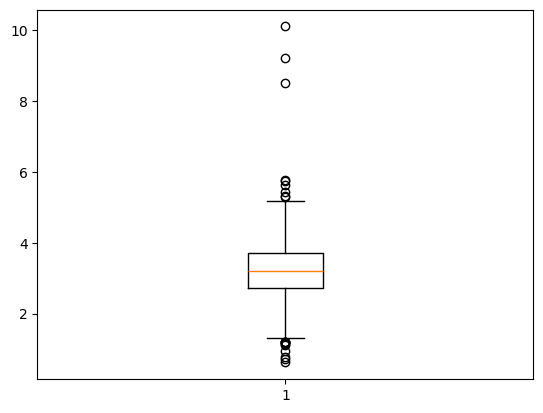

In [20]:
import matplotlib.pyplot as plt

plt.boxplot(x=prod['진동'])
plt.show()

In [21]:
Q1 = prod['진동'].quantile(0.25)
Q3 = prod['진동'].quantile(0.75)
IQR = Q3 - Q1

Lower = Q1 - 1.5*IQR
Upper = Q3 + 1.5*IQR

normal = prod['진동'].between(Lower, Upper)
normal_min = prod.loc[normal, '진동'].min()
normal_max = prod.loc[normal, '진동'].max()

prod.loc[prod['진동']>Upper, '진동'] = normal_max
prod.loc[prod['진동']<Lower, '진동'] = normal_min

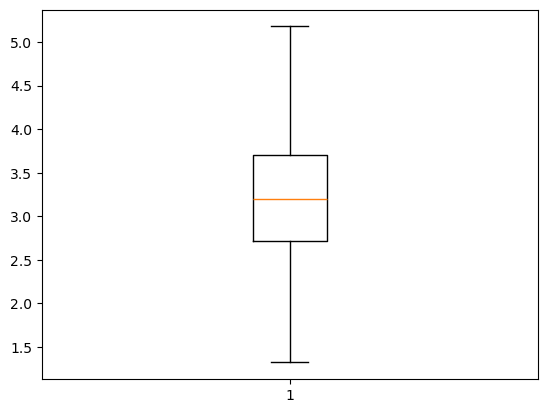

In [22]:
plt.boxplot(x=prod['진동'])
plt.show()

# 7. 생산일자를 날짜형으로 변환하고 생산월, 생산요일을 생성하시오.

In [23]:
from datetime import datetime, date

week = np.array(['월','화','수','목','금','토','일'])
prod['생산일자'] = pd.to_datetime(prod['생산일자'], format = '%Y-%m-%d')
prod['생산월'] = prod['생산일자'].dt.month
prod['생산요일'] = week[prod['생산일자'].dt.weekday]
prod.head()

,생산ID,생산일자,설비ID,작업자ID,제품유형,교대,생산수량,온도,압력,진동,사이클타임,불량수량,생산월,생산요일
0,JAN-00001,2026-01-12,M11,OP021,기어,야간,235,57.7,114.5,3.65,44.1,6,1,월
1,JAN-00002,2026-01-26,M12,OP006,브라켓,야간,109,50.4,101.1,4.10,47.2,5,1,월
2,JAN-00003,2026-01-29,M12,OP010,샤프트,야간,132,58.2,93.9,2.23,58.1,4,1,목
3,JAN-00004,2026-01-04,M02,OP024,하우징,야간,96,60.2,116.0,3.10,59.9,2,1,일
4,JAN-00005,2026-01-26,M06,OP030,샤프트,야간,230,51.5,98.4,4.18,53.6,6,1,월


# 8. 생산 데이터와 설비 정보를 merge하시오.
# 9. 생산 데이터와 작업자 정보를 merge하시오.

In [24]:
df = pd.merge(prod, machine, on = '설비ID', how = 'inner')
df.head()

,생산ID,생산일자,설비ID,작업자ID,제품유형,교대,생산수량,온도,압력,진동,사이클타임,불량수량,생산월,생산요일,라인,설비유형,제조사,도입연도
0,JAN-00001,2026-01-12,M11,OP021,기어,야간,235,57.7,114.5,3.65,44.1,6,1,월,L2,CNC,K-Tech,2019
1,JAN-00002,2026-01-26,M12,OP006,브라켓,야간,109,50.4,101.1,4.10,47.2,5,1,월,L3,조립기,K-Tech,2019
2,JAN-00003,2026-01-29,M12,OP010,샤프트,야간,132,58.2,93.9,2.23,58.1,4,1,목,L3,조립기,K-Tech,2019
3,JAN-00004,2026-01-04,M02,OP024,하우징,야간,96,60.2,116.0,3.10,59.9,2,1,일,L1,CNC,M-Works,2023
4,JAN-00005,2026-01-26,M06,OP030,샤프트,야간,230,51.5,98.4,4.18,53.6,6,1,월,L3,포장기,M-Works,2024


In [25]:
df_final = pd.merge(df, operator, on = '작업자ID', how = 'inner')
df_final.head()

,생산ID,생산일자,설비ID,작업자ID,제품유형,교대,생산수량,온도,압력,진동,사이클타임,불량수량,생산월,생산요일,라인,설비유형,제조사,도입연도,작업조,숙련도
0,JAN-00001,2026-01-12,M11,OP021,기어,야간,235,57.7,114.5,3.65,44.1,6,1,월,L2,CNC,K-Tech,2019,B조,중급
1,JAN-00002,2026-01-26,M12,OP006,브라켓,야간,109,50.4,101.1,4.10,47.2,5,1,월,L3,조립기,K-Tech,2019,B조,고급
2,JAN-00003,2026-01-29,M12,OP010,샤프트,야간,132,58.2,93.9,2.23,58.1,4,1,목,L3,조립기,K-Tech,2019,C조,중급
3,JAN-00004,2026-01-04,M02,OP024,하우징,야간,96,60.2,116.0,3.10,59.9,2,1,일,L1,CNC,M-Works,2023,C조,초급
4,JAN-00005,2026-01-26,M06,OP030,샤프트,야간,230,51.5,98.4,4.18,53.6,6,1,월,L3,포장기,M-Works,2024,B조,중급


# 10. join을 사용하여 생산 데이터에 설비 정보를 인덱스 기준으로 붙이는 예제를 작성하시오.

In [26]:
machine_info = machine.set_index('설비ID')

prod_machine = prod.set_index('설비ID').join(machine_info, how='left', rsuffix='설비정보')
prod_machine.reset_index(inplace=True)
prod_machine.head()

,설비ID,생산ID,생산일자,작업자ID,제품유형,교대,생산수량,온도,압력,진동,사이클타임,불량수량,생산월,생산요일,라인,설비유형,제조사,도입연도
0,M11,JAN-00001,2026-01-12,OP021,기어,야간,235,57.7,114.5,3.65,44.1,6,1,월,L2,CNC,K-Tech,2019
1,M12,JAN-00002,2026-01-26,OP006,브라켓,야간,109,50.4,101.1,4.10,47.2,5,1,월,L3,조립기,K-Tech,2019
2,M12,JAN-00003,2026-01-29,OP010,샤프트,야간,132,58.2,93.9,2.23,58.1,4,1,목,L3,조립기,K-Tech,2019
3,M02,JAN-00004,2026-01-04,OP024,하우징,야간,96,60.2,116.0,3.10,59.9,2,1,일,L1,CNC,M-Works,2023
4,M06,JAN-00005,2026-01-26,OP030,샤프트,야간,230,51.5,98.4,4.18,53.6,6,1,월,L3,포장기,M-Works,2024


# 11. iloc로 앞 5행과 일부 컬럼을 선택하시오.

In [27]:
df_final.iloc[:5,2:6]

,설비ID,작업자ID,제품유형,교대
0,M11,OP021,기어,야간
1,M12,OP006,브라켓,야간
2,M12,OP010,샤프트,야간
3,M02,OP024,하우징,야간
4,M06,OP030,샤프트,야간


# 12. loc로 야간 생산 데이터만 선택하시오.

In [28]:
night = df_final.loc[df_final['교대']=='야간']
night.head()

,생산ID,생산일자,설비ID,작업자ID,제품유형,교대,생산수량,온도,압력,진동,사이클타임,불량수량,생산월,생산요일,라인,설비유형,제조사,도입연도,작업조,숙련도
0,JAN-00001,2026-01-12,M11,OP021,기어,야간,235,57.7,114.5,3.65,44.1,6,1,월,L2,CNC,K-Tech,2019,B조,중급
1,JAN-00002,2026-01-26,M12,OP006,브라켓,야간,109,50.4,101.1,4.10,47.2,5,1,월,L3,조립기,K-Tech,2019,B조,고급
2,JAN-00003,2026-01-29,M12,OP010,샤프트,야간,132,58.2,93.9,2.23,58.1,4,1,목,L3,조립기,K-Tech,2019,C조,중급
3,JAN-00004,2026-01-04,M02,OP024,하우징,야간,96,60.2,116.0,3.10,59.9,2,1,일,L1,CNC,M-Works,2023,C조,초급
4,JAN-00005,2026-01-26,M06,OP030,샤프트,야간,230,51.5,98.4,4.18,53.6,6,1,월,L3,포장기,M-Works,2024,B조,중급


# 13. 양품수량, 불량률, 설비연식, 고불량여부 변수를 생성하시오.

In [29]:
df_final['양품수량'] = df_final['생산수량'] - df_final['불량수량']
df_final['불량률(%)'] = (df_final['불량수량'] / df_final['생산수량']*100).round(2)
df_final['설비연식(년)'] = datetime.now().year - df_final['도입연도']
df_final['고불량여부'] = '정상' 
df_final.loc[df_final['불량률(%)'] >= df_final['불량률(%)'].quantile(0.75),'고불량여부'] = '고불량' #불량률 상위 25%를 고불량비율로 정함

In [30]:
df_final.head()

,생산ID,생산일자,설비ID,작업자ID,제품유형,교대,생산수량,온도,압력,진동,...,라인,설비유형,제조사,도입연도,작업조,숙련도,양품수량,불량률(%),설비연식(년),고불량여부
0,JAN-00001,2026-01-12,M11,OP021,기어,야간,235,57.7,114.5,3.65,...,L2,CNC,K-Tech,2019,B조,중급,229,2.55,7,정상
1,JAN-00002,2026-01-26,M12,OP006,브라켓,야간,109,50.4,101.1,4.10,...,L3,조립기,K-Tech,2019,B조,고급,104,4.59,7,고불량
2,JAN-00003,2026-01-29,M12,OP010,샤프트,야간,132,58.2,93.9,2.23,...,L3,조립기,K-Tech,2019,C조,중급,128,3.03,7,고불량
3,JAN-00004,2026-01-04,M02,OP024,하우징,야간,96,60.2,116.0,3.10,...,L1,CNC,M-Works,2023,C조,초급,94,2.08,3,정상
4,JAN-00005,2026-01-26,M06,OP030,샤프트,야간,230,51.5,98.4,4.18,...,L3,포장기,M-Works,2024,B조,중급,224,2.61,2,정상


In [31]:
df_final['불량률(%)'].describe()

count    1070.000000
mean        2.251551
std         0.799424
min         0.000000
25%         1.722500
50%         2.200000
75%         2.750000
max         4.880000
Name: 불량률(%), dtype: float64

# 14. 불량률이 높은 야간 생산 데이터를 필터링하고 정렬하시오.

In [32]:
#df_final.loc[df_final['불량률(%)'] >= df_final['불량률(%)'].quantile(0.75)]
고불량 = df_final['불량률(%)'].quantile(0.75)
result = df_final.query("'불량률(%)'>='고불량' and 교대 =='야간'")
hn = result.sort_values(by = ['불량률(%)'], ascending = False)
hn.head()

,생산ID,생산일자,설비ID,작업자ID,제품유형,교대,생산수량,온도,압력,진동,...,라인,설비유형,제조사,도입연도,작업조,숙련도,양품수량,불량률(%),설비연식(년),고불량여부
250,JAN-00251,2026-01-27,M02,OP022,하우징,야간,82,47.3,98.2,4.13,...,L1,CNC,M-Works,2023,B조,중급,78,4.88,3,고불량
712,MAR-00023,2026-03-13,M09,OP029,브라켓,야간,246,54.2,101.8,4.56,...,L2,조립기,K-Tech,2022,B조,중급,234,4.88,4,고불량
184,JAN-00185,2026-01-09,M06,OP017,샤프트,야간,172,49.1,87.4,4.13,...,L3,포장기,M-Works,2024,B조,중급,164,4.65,2,고불량
105,JAN-00106,2026-01-03,M01,OP022,하우징,야간,152,50.2,111.0,4.11,...,L3,검사기,K-Tech,2022,B조,중급,145,4.61,4,고불량
1,JAN-00002,2026-01-26,M12,OP006,브라켓,야간,109,50.4,101.1,4.10,...,L3,조립기,K-Tech,2019,B조,고급,104,4.59,7,고불량


# 15. 라인과 교대별 평균 불량률을 집계하시오.

In [35]:
poor_mean = df_final.groupby(['라인', '교대']).agg({
    '불량률(%)' : 'mean'
}).rename(columns = {'불량률(%)' : '평균불량률'}).reset_index().round(2)

poor_mean

,라인,교대,평균불량률
0,L1,야간,2.70
1,L1,주간,1.93
2,L2,야간,2.54
3,L2,주간,2.01
4,L3,야간,2.56
5,L3,주간,2.05


# 16. 숙련도를 순서형 인코딩하시오.

In [36]:
df_final['숙련도'].value_counts()

숙련도
중급    590
고급    241
초급    239
Name: count, dtype: int64

In [39]:
df_final['숙련도인코딩'] = df_final['숙련도'].map({
    '초급' : 0,
    '중급' : 1,
    '고급' : 2
})
df_final.head()

,생산ID,생산일자,설비ID,작업자ID,제품유형,교대,생산수량,온도,압력,진동,...,설비유형,제조사,도입연도,작업조,숙련도,양품수량,불량률(%),설비연식(년),고불량여부,숙련도인코딩
0,JAN-00001,2026-01-12,M11,OP021,기어,야간,235,57.7,114.5,3.65,...,CNC,K-Tech,2019,B조,중급,229,2.55,7,정상,1
1,JAN-00002,2026-01-26,M12,OP006,브라켓,야간,109,50.4,101.1,4.10,...,조립기,K-Tech,2019,B조,고급,104,4.59,7,고불량,2
2,JAN-00003,2026-01-29,M12,OP010,샤프트,야간,132,58.2,93.9,2.23,...,조립기,K-Tech,2019,C조,중급,128,3.03,7,고불량,1
3,JAN-00004,2026-01-04,M02,OP024,하우징,야간,96,60.2,116.0,3.10,...,CNC,M-Works,2023,C조,초급,94,2.08,3,정상,0
4,JAN-00005,2026-01-26,M06,OP030,샤프트,야간,230,51.5,98.4,4.18,...,포장기,M-Works,2024,B조,중급,224,2.61,2,정상,1


# 17. 제품유형, 교대, 라인, 설비유형을 원-핫 인코딩하시오.

In [40]:
encoded_cols = ['제품유형','교대','라인','설비유형']

df_final_encoded = pd.get_dummies(
    df_final,
    columns = encoded_cols,
    dtype = int
)
df_final_encoded.head()

,생산ID,생산일자,설비ID,작업자ID,생산수량,온도,압력,진동,사이클타임,불량수량,...,제품유형_하우징,교대_야간,교대_주간,라인_L1,라인_L2,라인_L3,설비유형_CNC,설비유형_검사기,설비유형_조립기,설비유형_포장기
0,JAN-00001,2026-01-12,M11,OP021,235,57.7,114.5,3.65,44.1,6,...,0,1,0,0,1,0,1,0,0,0
1,JAN-00002,2026-01-26,M12,OP006,109,50.4,101.1,4.10,47.2,5,...,0,1,0,0,0,1,0,0,1,0
2,JAN-00003,2026-01-29,M12,OP010,132,58.2,93.9,2.23,58.1,4,...,0,1,0,0,0,1,0,0,1,0
3,JAN-00004,2026-01-04,M02,OP024,96,60.2,116.0,3.10,59.9,2,...,1,1,0,1,0,0,1,0,0,0
4,JAN-00005,2026-01-26,M06,OP030,230,51.5,98.4,4.18,53.6,6,...,0,1,0,0,0,1,0,0,0,1


# 18. 생산수량, 불량수량, 온도, 압력, 진동, 불량률을 스케일링하시오.

In [44]:
#from sklearn.preprocessing import MinMaxScaler

#scale_cols = ["총매출액", "할인액", "순매출액", "이익", "실매출액"]
#scaler = MinMaxScaler()
#df_input_model = order_encoded.copy()
#df_input_model[scale_cols] = scaler.fit_transform(df_input_model[scale_cols])

#df_input_model.head()

from sklearn.preprocessing import StandardScaler

scale_cols = ['생산수량','불량수량','온도','압력','진동','불량률(%)']
scaler = StandardScaler()
df_input_model = df_final_encoded.copy()
df_input_model[scale_cols] = scaler.fit_transform(df_input_model[scale_cols])

df_input_model.head()

,생산ID,생산일자,설비ID,작업자ID,생산수량,온도,압력,진동,사이클타임,불량수량,...,제품유형_하우징,교대_야간,교대_주간,라인_L1,라인_L2,라인_L3,설비유형_CNC,설비유형_검사기,설비유형_조립기,설비유형_포장기
0,JAN-00001,2026-01-12,M11,OP021,1.431402,0.446097,0.705024,0.558802,44.1,1.298965,...,0,1,0,0,1,0,1,0,0,0
1,JAN-00002,2026-01-26,M12,OP006,-1.148049,-0.769188,-0.392071,1.129613,47.2,0.729570,...,0,1,0,0,0,1,0,0,1,0
2,JAN-00003,2026-01-29,M12,OP010,-0.677197,0.529336,-0.981555,-1.242424,58.1,0.160176,...,0,1,0,0,0,1,0,0,1,0
3,JAN-00004,2026-01-04,M02,OP024,-1.414183,0.862291,0.827833,-0.138856,59.9,-0.978614,...,1,1,0,1,0,0,1,0,0,0
4,JAN-00005,2026-01-26,M06,OP030,1.329043,-0.586063,-0.613128,1.231091,53.6,1.298965,...,0,1,0,0,0,1,0,0,0,1


# 19. 최종 분석용 데이터와 모델 입력용 데이터를 CSV로 저장하시오.

In [46]:
#모델 입력용 데이터 : 스케일링 + 인코딩
prod_analysis = df_final.to_csv("./data/prod_analysis.csv",index=False)
prod_input_model = df_input_model.to_csv("./data/prod_input_model.csv",index=False)